In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-02-13 16:57:35--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-13 16:57:35 ERROR 404: Not Found.



In [1]:
!nvidia-smi

Sat Feb 14 13:45:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
tf.__version__

'2.19.0'

In [7]:
img_height,img_width=32,32
batch_size=20

train_ds=tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
test_ds=tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
val_ds=tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 130 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


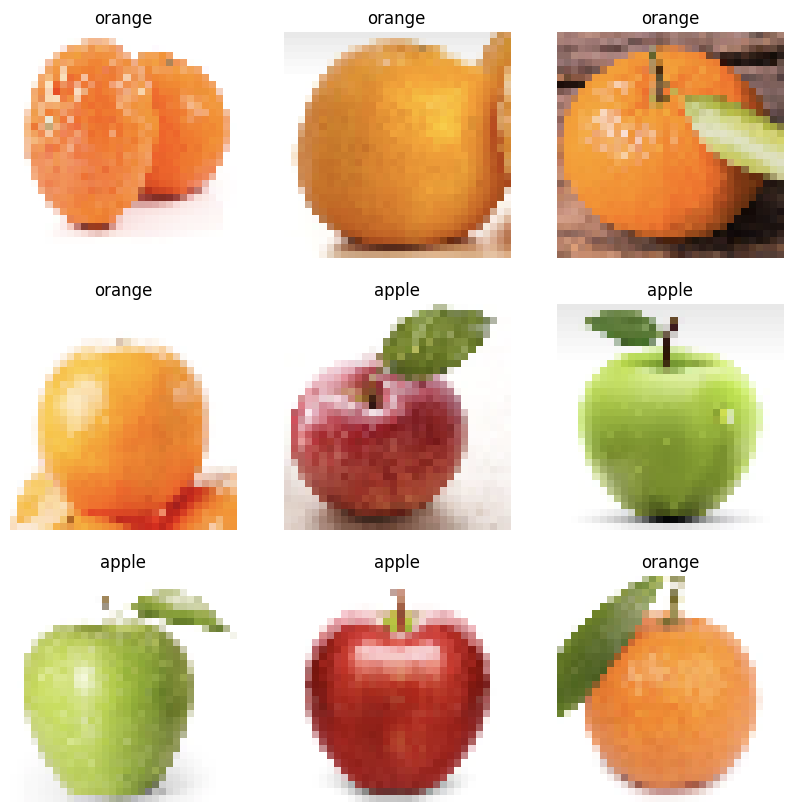

In [8]:
class_names=['apple','banana','orange']
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [14]:
model=tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation="softmax"),
        tf.keras.layers.Dense(3)
    ]
)

In [15]:
model.compile(
    optimizer="rmsprop",
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

In [16]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.3110 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.0971
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3518 - loss: 1.0955 - val_accuracy: 0.3939 - val_loss: 1.0562
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4455 - loss: 1.0622 - val_accuracy: 0.5000 - val_loss: 1.0090
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5339 - loss: 0.9994 - val_accuracy: 0.5303 - val_loss: 0.9605
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6165 - loss: 0.9558 - val_accuracy: 0.6212 - val_loss: 0.9279
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5905 - loss: 0.9431 - val_accuracy: 0.5606 - val_loss: 0.9245
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5923 - loss: 0.9384 - val_accuracy: 0.5758 - val_loss: 0.9145
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6111 - loss: 0.9085 - val_accuracy: 0.6364 

In [17]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.6543 - loss: 0.7538


[0.7603095769882202, 0.6692307591438293]

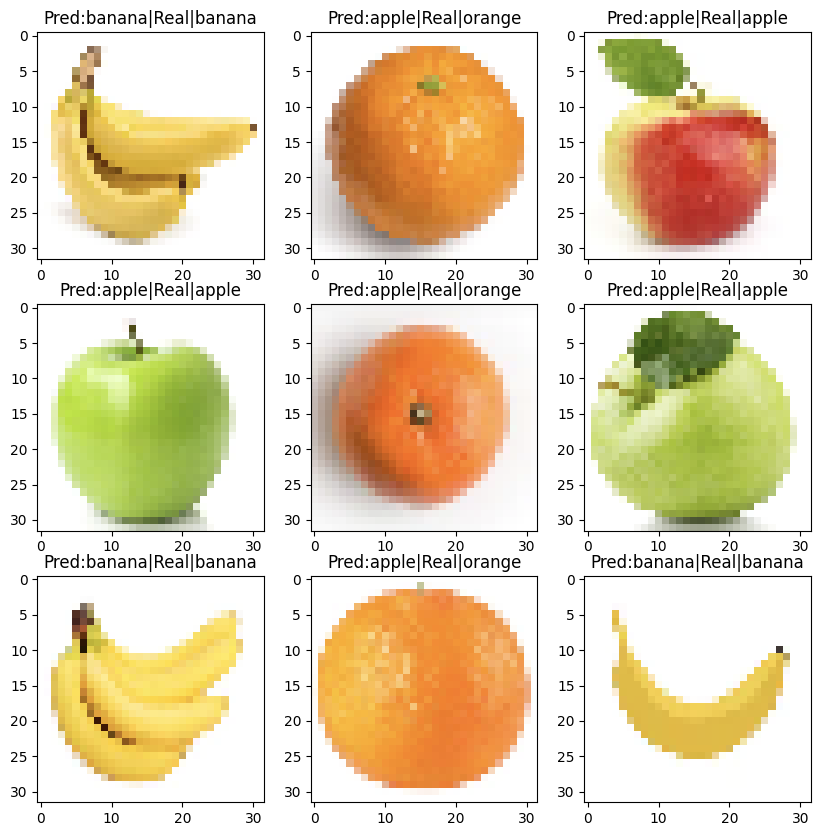

In [18]:
import numpy

plt.figure(figsize=(10,10))
for images,labels in test_ds.take(1):
  classifications=model(images)

  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index=numpy.argmax(classifications[i])
    plt.title("Pred:"+class_names[index]+"|Real|"+class_names[labels[i]])